# Phase 3 — Train Random Forest (README §4, §9)

**Inputs (frozen, §3.5):** `data/processed/train.csv` / `test.csv` — hash-verified against
`freeze_manifest.json` before anything runs. No columns added, no re-splitting; `test.csv`
is touched **exactly once**, at final evaluation.

**Outputs (§9 Phase 3):** model artifact (`models/rf_eff_rate.joblib`) + metrics
(`models/rf_metrics.json`, R², MAE, residual diagnostics).

**Spec requirements implemented:**
- `RandomForestRegressor` (scikit-learn) predicting `eff_rate` in **percentage scale** (§4.1, §3.3).
- Fixed `random_state=42` everywhere; **all** hyperparameters logged (§4.1).
- Categorical encoding documented (§4.1): **one-hot for all three categoricals**
  (`filing_status`, `marst`, `statefip`). Chosen over leave-one-out target encoding for
  `statefip` because one-hot introduces **no target-derived transform** — nothing fitted on
  `y` that could leak or be mis-applied downstream (§4.3 faithfulness > accuracy). SHAP will
  give one bar per state; those can be summed back into a single "state" contribution.
- Metrics: **R²** and **MAE** in effective-rate points (§4.2). Primary metrics are unweighted;
  `asecwt`-weighted versions are reported alongside (weights kept out of `X`, §3.4).
- Diagnostics: residual distribution, residuals vs. predicted, and residual bias across
  income levels (§4.2).

**Hyperparameter protocol (decision logged):** small 3-fold CV grid search **inside train.csv
only** over `max_depth × min_samples_leaf × max_features`, selected on MAE (the spec's named
unit). The search uses 200 trees per forest (ranking between configs is stable in tree count);
the final model is refit on all of train with **500 trees**. Deliberately small grid per §4.3:
the goal is a defensible leaf-size/depth choice, not squeezed accuracy.

**Known caveat carried from Phase 2:** the frozen split is row-random, not group-aware —
related filers from the same family can straddle train/test, so test R² may be mildly
optimistic. CV folds inherit the same property (the frozen table carries no group key,
and the freeze forbids adding one). Stated here per §4.2.

In [1]:
import hashlib, json, time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42

ROOT = Path.cwd()
while not (ROOT / "README.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
FIGURES = ROOT / "reports" / "figures"
MODELS.mkdir(exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Freeze verification (§3.5): refuse to train on anything but the frozen files ---
manifest = json.loads((PROCESSED / "freeze_manifest.json").read_text())

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

for fname in ("train.csv", "test.csv"):
    actual = sha256(PROCESSED / fname)
    assert actual == manifest["sha256"][fname], (
        f"{fname} does not match freeze_manifest.json — the freeze has drifted; refusing to train."
    )
print("Freeze verified: train.csv / test.csv match the manifest hashes.")

train_df = pd.read_csv(PROCESSED / "train.csv")
test_df  = pd.read_csv(PROCESSED / "test.csv")

FEATURE_COLS = manifest["feature_cols"]
TARGET = manifest["target"]
WEIGHT = manifest["weight_retained"]
assert list(train_df.columns) == FEATURE_COLS + [TARGET, WEIGHT]
assert list(test_df.columns)  == FEATURE_COLS + [TARGET, WEIGHT]
assert len(train_df) == manifest["rows"]["train"] and len(test_df) == manifest["rows"]["test"]

X_train, y_train, w_train = train_df[FEATURE_COLS], train_df[TARGET], train_df[WEIGHT]
X_test,  y_test,  w_test  = test_df[FEATURE_COLS],  test_df[TARGET],  test_df[WEIGHT]
print(f"train {X_train.shape}   test {X_test.shape}   target={TARGET} (percent scale)")

Freeze verified: train.csv / test.csv match the manifest hashes.
train (48984, 16)   test (12247, 16)   target=eff_rate (percent scale)


## Encoding (§4.1, decision documented)

`filing_status` (3 levels), `marst` (6), `statefip` (51) are one-hot encoded inside a
scikit-learn `Pipeline`, so the **saved artifact carries its own preprocessing** — Phases
4/5/7 load one object and feed it raw frozen-schema rows. Categories are fixed from the
train split; the encoder errors on unseen codes rather than silently zeroing them, and test
is asserted to contain no category train hasn't seen. Numeric features pass through
untouched (RF is scale-invariant; no standardization needed, §4.1).

In [2]:
CATEGORICAL = ["filing_status", "marst", "statefip"]
NUMERIC = [c for c in FEATURE_COLS if c not in CATEGORICAL]

# categories fixed from train; assert test introduces nothing new
categories = [np.sort(X_train[c].unique()) for c in CATEGORICAL]
for col, cats in zip(CATEGORICAL, categories):
    unseen = set(X_test[col].unique()) - set(cats)
    assert not unseen, f"test has {col} categories unseen in train: {unseen}"
    print(f"{col:15s} {len(cats)} levels")

encoder = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(categories=categories, sparse_output=False,
                                 handle_unknown="error"), CATEGORICAL),
        ("passthrough", "passthrough", NUMERIC),
    ],
    verbose_feature_names_out=False,
)

n_encoded = sum(len(c) for c in categories) + len(NUMERIC)
print(f"\nEncoded design matrix: {len(FEATURE_COLS)} features -> {n_encoded} columns")

filing_status   3 levels
marst           6 levels
statefip        51 levels

Encoded design matrix: 16 features -> 73 columns


## Hyperparameter search — 3-fold CV inside train only

Grid: `max_depth ∈ {None, 16}` × `min_samples_leaf ∈ {2, 5, 20}` × `max_features ∈ {'sqrt', 0.5}`
(12 configurations). Selection metric: **MAE** (§4.2's named unit). `n_estimators=200`
during the search; more trees only reduce variance and do not change the ranking, and the
final model gets 500. Every fold, seed, and score is logged to `rf_metrics.json`.

In [3]:
pipe = Pipeline([
    ("encode", encoder),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1)),
])

PARAM_GRID = {
    "rf__max_depth":        [None, 16],
    "rf__min_samples_leaf": [2, 5, 20],
    "rf__max_features":     ["sqrt", 0.5],
}

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(
    pipe, PARAM_GRID, cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1, return_train_score=True, verbose=1,
)
t0 = time.time()
search.fit(X_train, y_train)
print(f"\nSearch done in {time.time() - t0:,.0f}s")

cv_tbl = pd.DataFrame(search.cv_results_)[
    ["param_rf__max_depth", "param_rf__min_samples_leaf", "param_rf__max_features",
     "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]
].sort_values("rank_test_score")
cv_tbl[["mean_test_score", "mean_train_score"]] = -cv_tbl[["mean_test_score", "mean_train_score"]]
cv_tbl = cv_tbl.rename(columns={"mean_test_score": "cv_MAE", "mean_train_score": "train_MAE"})
print("\nAll 12 configurations (MAE in effective-rate points, lower = better):")
print(cv_tbl.to_string(index=False))
BEST = {k.replace("rf__", ""): v for k, v in search.best_params_.items()}
print("\nSelected:", BEST, f"  (CV MAE {-search.best_score_:.4f})")

Fitting 3 folds for each of 12 candidates, totalling 36 fits



Search done in 181s

All 12 configurations (MAE in effective-rate points, lower = better):
param_rf__max_depth  param_rf__min_samples_leaf param_rf__max_features   cv_MAE  std_test_score  train_MAE  rank_test_score
               None                           2                    0.5 1.319296        0.003075   0.714223                1
                 16                           2                    0.5 1.327480        0.003238   0.824387                2
               None                           5                    0.5 1.355092        0.002853   1.019769                3
                 16                           5                    0.5 1.357833        0.003074   1.045334                4
               None                          20                    0.5 1.488065        0.005151   1.364829                5
                 16                          20                    0.5 1.491748        0.002344   1.367733                6
               None                     

In [4]:
# --- Final model: best config, 500 trees, refit on ALL of train ------------------
rf_final = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=True,          # free bootstrap-held-out sanity check, no extra data spent
    **BEST,
)
model = Pipeline([("encode", encoder), ("rf", rf_final)])

t0 = time.time()
model.fit(X_train, y_train)
fit_seconds = time.time() - t0
oob_r2 = model.named_steps["rf"].oob_score_
print(f"Final fit: 500 trees in {fit_seconds:,.0f}s   OOB R² = {oob_r2:.4f}")

Final fit: 500 trees in 26s   OOB R² = 0.9086


In [5]:
# --- Evaluation (§4.2): test.csv touched exactly once ----------------------------
pred_train = model.predict(X_train)
pred_test  = model.predict(X_test)   # <- the single use of test

def w_r2(y, p, w):
    y, p, w = map(np.asarray, (y, p, w))
    ybar = np.average(y, weights=w)
    return 1 - np.average((y - p) ** 2, weights=w) / np.average((y - ybar) ** 2, weights=w)

metrics = {
    "train": {"R2": r2_score(y_train, pred_train),
              "MAE": mean_absolute_error(y_train, pred_train)},
    "oob":   {"R2": oob_r2},
    "test":  {"R2": r2_score(y_test, pred_test),
              "MAE": mean_absolute_error(y_test, pred_test)},
    "test_weighted_asecwt": {"R2": w_r2(y_test, pred_test, w_test),
                             "MAE": mean_absolute_error(y_test, pred_test,
                                                        sample_weight=w_test)},
}
print("Metrics (eff_rate is in percentage points, so MAE is in rate points):\n")
print(pd.DataFrame(metrics).T.round(4).to_string())
print(f"\nBaseline MAE (predict train mean everywhere): "
      f"{mean_absolute_error(y_test, np.full(len(y_test), y_train.mean())):.3f} rate points")
print("Train-vs-test gap and OOB-vs-test agreement are the overfit checks; "
      "row-random split caveat applies (header note).")

Metrics (eff_rate is in percentage points, so MAE is in rate points):

                          R2     MAE
train                 0.9703  0.6971
oob                   0.9086     NaN
test                  0.9005  1.2770
test_weighted_asecwt  0.9023  1.1928

Baseline MAE (predict train mean everywhere): 6.365 rate points
Train-vs-test gap and OOB-vs-test agreement are the overfit checks; row-random split caveat applies (header note).


## Residual diagnostics (§4.2)

Three required views: **(a)** residual distribution, **(b)** residuals vs. predicted,
**(c)** systematic bias across **income levels** — mean/median residual per `unit_inctot`
decile. Residual = actual − predicted, in rate points; positive = model under-predicts.

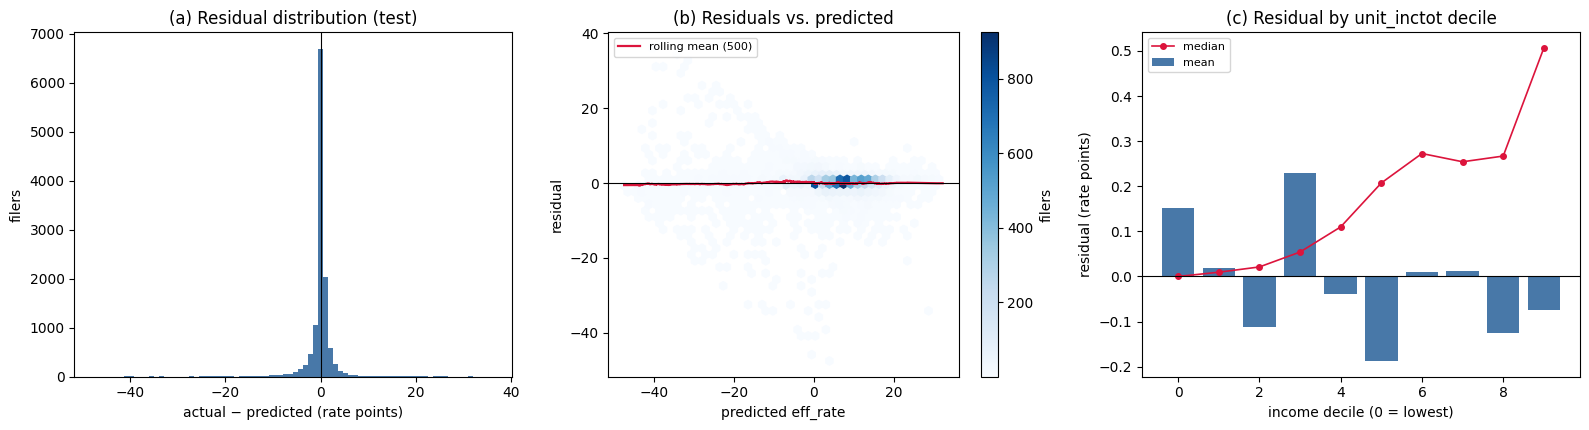

Residual bias by income decile (rate points):
          inc_lo     inc_hi  mean_resid  median_resid     n
decile                                                     
0            1.0    22000.0       0.151        -0.000  1245
1        22001.0    32075.0       0.019         0.009  1205
2        32100.0    43000.0      -0.112         0.021  1238
3        43001.0    53097.0       0.228         0.054  1211
4        53098.0    67520.0      -0.040         0.110  1225
5        67550.0    85699.0      -0.187         0.207  1224
6        85710.0   110062.0       0.011         0.273  1225
7       110071.0   148420.0       0.011         0.254  1225
8       148485.0   213700.0      -0.125         0.267  1224
9       213760.0  1672866.0      -0.075         0.506  1225


In [6]:
resid = y_test - pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

# (a) residual distribution
axes[0].hist(resid, bins=80, color="#4878a8", edgecolor="none")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_title("(a) Residual distribution (test)")
axes[0].set_xlabel("actual − predicted (rate points)")
axes[0].set_ylabel("filers")

# (b) residuals vs predicted
hb = axes[1].hexbin(pred_test, resid, gridsize=45, cmap="Blues", mincnt=1)
order = np.argsort(pred_test)
roll = pd.Series(resid.to_numpy()[order]).rolling(500, center=True, min_periods=100).mean()
axes[1].plot(np.sort(pred_test), roll, color="crimson", lw=1.6, label="rolling mean (500)")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("(b) Residuals vs. predicted")
axes[1].set_xlabel("predicted eff_rate")
axes[1].set_ylabel("residual")
axes[1].legend(loc="upper left", fontsize=8)
fig.colorbar(hb, ax=axes[1], label="filers")

# (c) bias across income levels
inc_test = X_test["unit_inctot"]
deciles = pd.qcut(inc_test, 10, labels=False, duplicates="drop")
bias = pd.DataFrame({"resid": resid, "decile": deciles, "inc": inc_test}).groupby("decile").agg(
    inc_lo=("inc", "min"), inc_hi=("inc", "max"),
    mean_resid=("resid", "mean"), median_resid=("resid", "median"), n=("resid", "size"),
)
axes[2].bar(bias.index, bias["mean_resid"], color="#4878a8", label="mean")
axes[2].plot(bias.index, bias["median_resid"], "o-", color="crimson", ms=4, lw=1.2, label="median")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_title("(c) Residual by unit_inctot decile")
axes[2].set_xlabel("income decile (0 = lowest)")
axes[2].set_ylabel("residual (rate points)")
axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / "phase3_residual_diagnostics.png", dpi=150)
plt.show()

print("Residual bias by income decile (rate points):")
print(bias.round(3).to_string())
bias_by_decile = {int(k): {"mean": round(v["mean_resid"], 4), "median": round(v["median_resid"], 4),
                           "inc_lo": float(v["inc_lo"]), "inc_hi": float(v["inc_hi"]), "n": int(v["n"])}
                  for k, v in bias.iterrows()}

In [7]:
# --- Persist artifact + full metrics log (§9 Phase 3 outputs) --------------------
ARTIFACT = MODELS / "rf_eff_rate.joblib"
joblib.dump(model, ARTIFACT, compress=3)

feature_names_out = list(model.named_steps["encode"].get_feature_names_out())

log = {
    "phase": 3,
    "spec": "README §4 (model, metrics, faithfulness), §9 Phase 3",
    "inputs": {
        "train.csv_sha256": manifest["sha256"]["train.csv"],
        "test.csv_sha256": manifest["sha256"]["test.csv"],
        "feature_cols": FEATURE_COLS,
        "target": TARGET,
        "target_scale": "percent (eff_rate = 100 * fedtaxac / adjginc)",
    },
    "encoding": {
        "choice": "one-hot for filing_status, marst, statefip (documented per §4.1); "
                  "no target-derived transform",
        "categorical": CATEGORICAL,
        "n_encoded_columns": len(feature_names_out),
        "categories": {c: [int(v) for v in cats] for c, cats in zip(CATEGORICAL, categories)},
    },
    "search": {
        "protocol": "GridSearchCV, KFold(3, shuffle=True, random_state=42), train.csv only, "
                    "scoring=neg_mean_absolute_error, n_estimators=200 during search",
        "grid": {k.replace("rf__", ""): [str(v) for v in vs] for k, vs in PARAM_GRID.items()},
        "results": json.loads(cv_tbl.to_json(orient="records")),
        "selected": {k: str(v) for k, v in BEST.items()},
        "cv_mae_selected": round(-search.best_score_, 4),
    },
    "final_model": {
        "class": "sklearn.ensemble.RandomForestRegressor",
        "sklearn_version": sklearn.__version__,
        "hyperparameters": {k: (str(v) if not isinstance(v, (int, float, bool, type(None))) else v)
                            for k, v in model.named_steps["rf"].get_params().items()},
        "fit_seconds": round(fit_seconds, 1),
        "artifact": str(ARTIFACT.relative_to(ROOT)),
        "artifact_sha256": sha256(ARTIFACT),
        "artifact_mb": round(ARTIFACT.stat().st_size / 1e6, 1),
    },
    "metrics": {k: {m: round(v, 4) for m, v in d.items()} for k, d in metrics.items()},
    "residual_bias_by_income_decile": bias_by_decile,
    "caveats": [
        "Row-random (not group-aware) frozen split: related filers can straddle train/test; "
        "test R² may be mildly optimistic. CV folds inherit the same property.",
        "Weighted metrics use asecwt on the test split only; weights never entered X (§3.4).",
    ],
}
(MODELS / "rf_metrics.json").write_text(json.dumps(log, indent=2) + "\n")

print("Wrote", ARTIFACT.relative_to(ROOT), f"({log['final_model']['artifact_mb']} MB)")
print("Wrote", (MODELS / "rf_metrics.json").relative_to(ROOT))
print("\nTop feature importances (impurity-based; SHAP in Phase 4 is the real attribution):")
imp = pd.Series(model.named_steps["rf"].feature_importances_, index=feature_names_out)
print(imp.sort_values(ascending=False).head(12).round(4).to_string())

Wrote models/rf_eff_rate.joblib (275.7 MB)
Wrote models/rf_metrics.json

Top feature importances (impurity-based; SHAP in Phase 4 is the real attribution):
unit_inctot        0.5166
filing_status_5    0.1050
filing_status_4    0.0956
nchild             0.0716
age                0.0385
interest_share     0.0308
wage_share         0.0252
famsize            0.0242
filing_status_1    0.0177
marst_1            0.0168
socsec_share       0.0108
dividend_share     0.0097


## Definition of Done — Phase 3

- [x] Random Forest trained on the frozen `train.csv` (hash-verified), `random_state=42`,
      all hyperparameters + full CV results logged to `models/rf_metrics.json`.
- [x] Encoding decision documented (§4.1): one-hot, no target-derived transform.
- [x] R² + MAE reported (unweighted primary, `asecwt`-weighted supplement); baseline MAE for scale.
- [x] Residual diagnostics: distribution, vs-predicted, and bias by income decile
      (`reports/figures/phase3_residual_diagnostics.png`).
- [x] Model artifact saved: `models/rf_eff_rate.joblib` — a full `Pipeline`
      (one-hot encoder + forest), so downstream phases feed it **raw frozen-schema rows**.

**Handoff to Phases 4/5/6 (parallel per §9):**
```python
model = joblib.load("models/rf_eff_rate.joblib")
rf    = model.named_steps["rf"]                    # tree model for shap.TreeExplainer
Xt    = model.named_steps["encode"].transform(X)   # encoded matrix the explainer needs
names = model.named_steps["encode"].get_feature_names_out()
```
- Phase 4 (SHAP): explain `rf` on `Xt`; per-state one-hot bars can be summed into one
  "state" contribution for the waterfall.
- Phase 5 (twins): flip `filing_status` 5 → 1 on a raw row and call `model.predict` —
  the pipeline re-encodes; hold `unit_inctot` and shares constant.
- Phase 6 (validation): weight by `asecwt`, keep IRS SOI and CPS numbers separate (§6).